## 1 - Model 3 Neural Network
While tree-based ensemble models such as Random Forest are widely regarded as strong baselines for intrusion detection on NSL-KDD, neural networks remain an important complementary modeling family. Prior studies show that Multi-Layer Perceptrons (MLPs) and related neural architectures are capable of capturing complex non-linear relationships between network traffic features and attack patterns, particularly when interactions between attributes are subtle or highly overlapping (Abrar et al., 2020; Hong et al., 2021; Rawat & Srinivasan, 2019; Hegde et al., 2024).

However, the literature also emphasizes that neural networks do not automatically outperform classical machine-learning methods on NSL-KDD. Their performance is highly sensitive to preprocessing choices, feature scaling, class imbalance, architecture design, and regularization. In several comparative studies, such as Abrar et al. (2020), Hong et al. (2021), and Hegde et al. (2024),neural networks achieve competitive results but are often matched or surpassed by tree-based ensembles in terms of accuracy, robustness, and interpretability. As a result, neural networks are best viewed not as a guaranteed upgrade, but as a more expressive alternative whose benefits must be empirically validated.

Hence, the purpose of introducing a neural network is therefore focused on empirical validation rather than assumed superiority. After establishing strong baselines with logistic regression and Random Forest, the neural network serves as a controlled experiment to assess whether additional representational capacity translates into measurable gains on NSL-KDD, particularly in the multi-class setting. 

Main objectives of this model are to:
* Assess whether a non-linear, fully connected neural network can improve multi-class detection performance compared to linear models and tree-based ensembles
* Evaluate the sensitivity of neural networks to feature scaling, class imbalance, and label distribution in NSL-KDD
* Compare predictive performance using standard metrics (accuracy, macro-F1, per-class recall) under the same data splits used for previous models
* Analyze training dynamics (loss curves, convergence behavior) to identify overfitting or underfitting tendencies
* Position neural networks fairly within the overall modeling pipeline, without assuming superiority over simpler or more interpretable methods


## 1 - Packages

In [24]:
# Start by importing all required libs...
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, roc_curve, auc, f1_score, accuracy_score, precision_score, recall_score, average_precision_score
from utils import load_split
import joblib

%matplotlib inline
plt.style.use('./deeplearning.mplstyle')
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)
np.set_printoptions(precision=2)

print("All packages loaded successfully.")

All packages loaded successfully.


## 2 - Loading data

In [3]:
DATA_DIR   = Path("data/processed")

X_train, y_train = load_split("train", DATA_DIR)
X_val,   y_val   = load_split("val", DATA_DIR)
X_test,  y_test  = load_split("test", DATA_DIR)

print ('The shape of X is: ' + str(X_train.shape))
print ('The shape of y is: ' + str(y_train.shape))

The shape of X is: (100778, 41)
The shape of y is: (100778,)


## 3 - Normalising data and converting multiclass to binary

In [4]:
# PV: alternative option in line with previous models (reuse encoder)
y_encoder = joblib.load("data/processed/label_encoder.joblib")
classes = y_encoder.classes_
normal_id = np.where(classes == "normal")[0][0]
print("Normal class: ", normal_id)

y_train_bin = (y_train != normal_id).astype(int)
y_val_bin   = (y_val   != normal_id).astype(int)
y_test_bin  = (y_test  != normal_id).astype(int)

print(pd.Series(y_train_bin).value_counts())

# some nn params
input_shape = (X_train.shape[1],) 
num_classes = len(y_encoder.classes_) # not hard coded num_classes = 40

Normal class:  16
0    53874
1    46904
Name: count, dtype: int64


## 4 - Multi-classification

### 4.1 – Model 3MCv1: Multiclass neural network

This model applies a feed-forward neural network to the multi-class NSL-KDD intrusion detection task. The network consists of two fully connected hidden layers with ReLU activations and a softmax output layer, enabling it to learn non-linear relationships between features and attack classes. Class labels are kept as integer-encoded targets and optimized using sparse categorical cross-entropy, which is mathematically equivalent to one-hot encoding with categorical cross-entropy while simplifying preprocessing and reducing memory overhead. Dropout regularisation is applied after each hidden layer to mitigate overfitting by randomly deactivating a fraction of neurons during training, encouraging more robust feature representations and improved generalisation.


In [10]:

print("Building model 3MCv1")
model_3MCv1 = Sequential([
    Dense(128, activation='relu', input_shape=input_shape),
    Dropout(0.3), 
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_3MCv1.compile(optimizer='adam', 
                loss='sparse_categorical_crossentropy', # instead of categorical_crossentropy
                metrics=['accuracy'])

# Train
print("Training  model 3MCv1...")
history_3MCv1 = model_3MCv1.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Building model 3MCv1
Training  model 3MCv1...
Epoch 1/50


/home/piet/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9540 - loss: 0.1998 - val_accuracy: 0.9896 - val_loss: 0.0448
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9827 - loss: 0.0613 - val_accuracy: 0.9890 - val_loss: 0.0360
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9861 - loss: 0.0487 - val_accuracy: 0.9902 - val_loss: 0.0326
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9872 - loss: 0.0425 - val_accuracy: 0.9910 - val_loss: 0.0284
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9885 - loss: 0.0384 - val_accuracy: 0.9915 - val_loss: 0.0268
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9892 - loss: 0.0359 - val_accuracy: 0.9927 - val_loss: 0.0256
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9900 - loss: 0.0339 - val_accuracy: 0.9926 - val_loss: 0.0239
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9908 - loss: 0.0307 - val_accurac

In [11]:
# Prediction and accuracy Model 3MCv1
test_loss_3MCv1, test_acc_3MCv1 = model_3MCv1.evaluate(X_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc_3MCv1*100:.2f}%")

y_pred_3MCv1_probs = model_3MCv1.predict(X_test)

y_pred_3MCv1 = np.argmax(y_pred_3MCv1_probs, axis=1)

print("Classification report 3MCv1")

report = classification_report(y_test, y_pred_3MCv1, output_dict=True)
print(classification_report(y_test, y_pred_3MCv1))  

705/705 - 2s - 2ms/step - accuracy: 0.7096 - loss: 19.0909

Test Accuracy: 70.96%
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 955us/step
Classification report 3MCv1
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       737
           1       0.99      0.89      0.94       359
           2       0.67      0.20      0.31        20
           3       0.08      0.33      0.12         3
           4       0.00      0.00      0.00      1231
           5       0.00      0.00      0.00       133
           6       0.00      0.00      0.00         1
           7       0.75      0.98      0.85       141
           8       1.00      1.00      1.00         7
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00       293
          11       0.00      0.00      0.00       996
          12       0.00      0.00      0.00        18
          13       0.00      0.00      0.00        17
          14       0.95      1.00   

/home/piet/.pyenv/versions/3.12.3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/piet/.pyenv/versions/3.12.3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/piet/.pyenv/versions/3.12.3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", l

Although Model 3MCv1 achieved high validation accuracy during training, its test performance reveals a strong dependence on majority classes. While overall accuracy reaches approximately 71%, the macro-averaged F1-score remains low (+/- 0.25), indicating poor recall for rare attack categories. This highlights the limitations of standard neural networks on highly imbalanced intrusion-detection datasets such as NSL-KDD and confirms that accuracy alone is insufficient for evaluating multi-class intrusion detection performance.

### 4.2 - Model 3MCv2: Neural network with L1 regularisation and early stopping mechanism

In model 3mcv2 L1 regularisation is applied to the dense layers by adding an L1 penalty to the loss function during training. This penalty is proportional to the absolute magnitude of the network weights and encourages sparsity by driving less informative weights toward zero. In the context of intrusion detection, where many input features may be redundant or weakly informative, L1 regularisation helps reduce model complexity and therefore limits overfitting. Early stopping is applied to prevent unnecessary training once validation loss stops improving, improving generalisation.


In [12]:
# print("Building Model 3MCv2 (L1 Regularized and early stopping)")

# model_3MCv2 = Sequential([
#     Dense(128, activation='relu', 
#                  input_shape=input_shape,
#                  kernel_regularizer=tf.keras.regularizers.l1(0.001)), 
#     Dropout(0.3), 
#     Dense(64, activation='relu'),
#     Dropout(0.3),
#     Dense(num_classes, activation='softmax')
# ])

# model_3MCv2.compile(optimizer='adam', 
#                 loss='sparse_categorical_crossentropy', 
#                 metrics=['accuracy'])

# print("Starting training...")
# early_stopping = EarlyStopping(
#     monitor='val_loss', 
#     patience=3, 
#     restore_best_weights=True
# )

# history_3MCv2 = model_3MCv2.fit(
#     X_train, y_train,
#     epochs=50,
#     batch_size=64,
#     validation_data=(X_val, y_val),
#     callbacks=[early_stopping],
#     verbose=1
# )
print("Building model 3mcv2 l1 regularised")

reg = tf.keras.regularizers.l1(1e-4)

model_3MCv2 = Sequential([
    Dense(128, activation="relu", input_shape=input_shape, kernel_regularizer=reg),
    Dropout(0.3),
    Dense(64, activation="relu", kernel_regularizer=reg),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

model_3MCv2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=1e-4,
    restore_best_weights=True
)

print("Starting training")

history_3MCv2 = model_3MCv2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)


Building model 3mcv2 l1 regularised
Starting training
Epoch 1/50


/home/piet/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9551 - loss: 0.2955 - val_accuracy: 0.9877 - val_loss: 0.1457
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9828 - loss: 0.1476 - val_accuracy: 0.9883 - val_loss: 0.1165
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9852 - loss: 0.1204 - val_accuracy: 0.9889 - val_loss: 0.0990
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9860 - loss: 0.1084 - val_accuracy: 0.9899 - val_loss: 0.0901
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9866 - loss: 0.0995 - val_accuracy: 0.9910 - val_loss: 0.0855
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9870 - loss: 0.0946 - val_accuracy: 0.9908 - val_loss: 0.0814
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9875 - loss: 0.0911 - val_accuracy: 0.9908 - val_loss: 0.0759
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9878 - loss: 0.0870 - val_accurac

In [13]:
# Prediction and accuracy Model 3MCv2
test_loss_3MCv2, test_acc_3MCv2 = model_3MCv2.evaluate(X_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc_3MCv2*100:.2f}%")

y_pred_3MCv2_probs = model_3MCv2.predict(X_test)

y_pred_3MCv2 = np.argmax(y_pred_3MCv2_probs, axis=1)

print("--- Classification Report 3MCv2 ---")
report = classification_report(y_test, y_pred_3MCv2, output_dict=True)
print(classification_report(y_test, y_pred_3MCv2))

705/705 - 2s - 2ms/step - accuracy: 0.7098 - loss: 5.3417

Test Accuracy: 70.98%
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
--- Classification Report 3MCv2 ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       737
           1       0.99      0.95      0.97       359
           2       0.00      0.00      0.00        20
           3       0.00      0.00      0.00         3
           4       0.50      0.00      0.00      1231
           5       0.00      0.00      0.00       133
           6       0.00      0.00      0.00         1
           7       0.78      0.97      0.86       141
           8       1.00      1.00      1.00         7
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00       293
          11       0.00      0.00      0.00       996
          12       0.00      0.00      0.00        18
          13       0.00      0.00      0.00        17
          14       0.95      1.

/home/piet/.pyenv/versions/3.12.3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/piet/.pyenv/versions/3.12.3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/piet/.pyenv/versions/3.12.3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", l

Introducing L1 regularisation and early stopping stabilised training and reduced the magnitude of the loss, indicating improved control over model complexity. However, test accuracy remained unchanged and the macro-averaged F1-score decreased slightly. This suggests that regularisation alone does not address the primary limitation of the neural network, namely its poor performance on minority attack classes due to severe class imbalance. Since regularisation alone does not improve detection of rare attack classes, the next model explicitly addresses class imbalance by introducing cost-sensitive learning through class weighting.

### 4.3 - Model 3MCv3: Neural network with class weighting

To address the severe class imbalance observed in the NSL-KDD dataset, Model 3MCv3 incorporates class weighting during training. Class weights are computed from the training labels using the balanced weighting scheme, which assigns higher weights to underrepresented classes and lower weights to majority classes based on their relative frequencies. These weights are passed to the training procedure and directly modify the loss function by scaling the contribution of each sample according to its class.

Concretely, during optimisation, misclassification errors for rare attack classes incur a larger penalty than errors on frequent classes. This forces the network to allocate more capacity to minority classes that would otherwise have a negligible impact on the overall loss. Importantly, the network architecture and optimisation algorithm remain unchanged; only the relative importance of training samples is adjusted. This ensures that any observed performance differences can be attributed to imbalance-aware learning rather than increased model capacity.

By integrating class weighting at the loss level, the model explicitly targets improvements in recall and macro-averaged F1-score, which are more informative metrics for multi-class intrusion detection than overall accuracy under strong class imbalance.

In [7]:
print("Building model 3mcv3 class weighted")

model_3MCv3 = Sequential([
    Dense(128, activation="relu", input_shape=input_shape),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

model_3MCv3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=1e-4,
    restore_best_weights=True
)

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}

print("Starting training")

history_3MCv3 = model_3MCv3.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    class_weight=class_weight,
    verbose=1
)


Building model 3mcv3 class weighted
Starting training
Epoch 1/50


/home/piet/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-12-13 12:02:34.086400: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-13 12:02:34.746669: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1042', 1052 bytes spill stores, 1052 bytes spill loads



1575/1575 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6226 - loss: 4.4093 - val_accuracy: 0.5691 - val_loss: 0.8074
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6905 - loss: 2.1292 - val_accuracy: 0.8787 - val_loss: 0.5870
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7569 - loss: 1.2605 - val_accuracy: 0.8862 - val_loss: 0.5205
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7835 - loss: 1.2979 - val_accuracy: 0.8781 - val_loss: 0.5351
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8130 - loss: 0.9385 - val_accuracy: 0.8851 - val_loss: 0.4630
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8401 - loss: 0.8819 - val_accuracy: 0.8844 - val_loss: 0.4443
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8447 - loss: 0.9210 - val_accuracy: 0.8986 - val_loss: 0.3737
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8546 - loss: 0.7118 - val_accurac

In [ ]:
# Prediction and accuracy Model 3MCv3
test_loss_3MCv3, test_acc_3MCv3 = model_3MCv3.evaluate(X_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc_3MCv3*100:.2f}%")

y_pred_3MCv3_probs = model_3MCv3.predict(X_test)

y_pred_3MCv3 = np.argmax(y_pred_3MCv3_probs, axis=1)

print("--- Classification Report 3MCv3 ---")
report = classification_report(y_test, y_pred_3MCv3, output_dict=True)
print(classification_report(y_test, y_pred_3MCv3))

705/705 - 2s - 2ms/step - accuracy: 0.7028 - loss: 7.8687

Test Accuracy: 70.28%
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 985us/step
--- Classification Report 3MCv2 ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       737
           1       0.35      0.99      0.52       359
           2       0.39      0.60      0.47        20
           3       0.01      0.67      0.01         3
           4       0.96      0.20      0.33      1231
           5       0.00      0.00      0.00       133
           6       0.00      0.00      0.00         1
           7       0.67      0.97      0.80       141
           8       1.00      1.00      1.00         7
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00       293
          11       0.00      0.00      0.00       996
          12       0.00      0.11      0.01        18
          13       0.00      0.00      0.00        17
          14       0.89      

/home/piet/.pyenv/versions/3.12.3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/piet/.pyenv/versions/3.12.3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/piet/.pyenv/versions/3.12.3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", l

Model 3MCv3 explicitly addressed class imbalance through class-weighted training, leading to an increase in macro-averaged recall and improved sensitivity to rare attack categories. However, this gain came at the cost of reduced precision and did not translate into a clear improvement in macro F1-score. Overall accuracy remained largely unchanged across all variants. These results indicate a fundamental trade-off between overall classification accuracy and minority-class detection when using standard neural networks on NSL-KDD. Without more advanced imbalance-aware techniques or architectural changes, neural networks do not provide a clear advantage over tree-based ensemble methods for multi-class intrusion detection in this setting.

### 4.4 - Accuracy and loss comparison of both multi-classclassification models over epochs

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 765us/step
705/705 - 1s - 1ms/step - accuracy: 0.7096 - loss: 19.0909
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 632us/step
705/705 - 1s - 1ms/step - accuracy: 0.7098 - loss: 5.3417
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 793us/step
705/705 - 1s - 2ms/step - accuracy: 0.7028 - loss: 7.8687


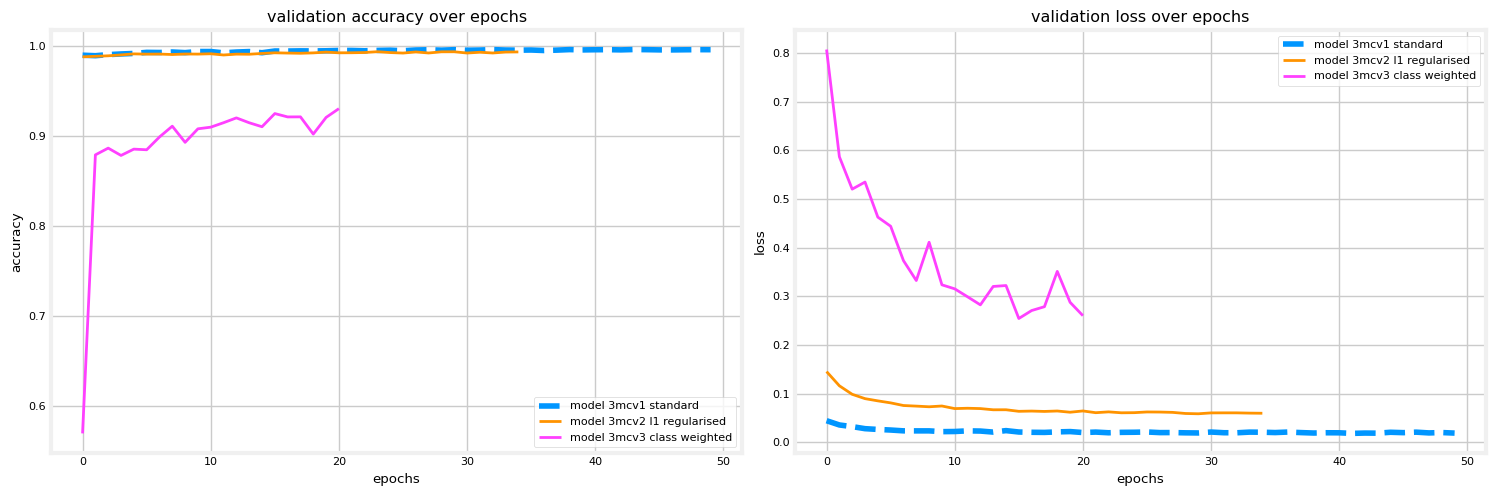

Final project results
          Metric Model 3mcv1 standard Model 3mcv2 l1 regularised  \
0  Test accuracy               70.96%                     70.98%   
1       Macro f1                 0.24                       0.21   
2   Macro recall                 0.30                       0.26   

  Model 3mcv3 class weighted  
0                     70.28%  
1                       0.23  
2                       0.33  


In [ ]:
# plt.close('all') 
# # Create a clean figure with two subplots (Accuracy and Loss)
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# # Plot 1: Validation Accuracy Comparison
# ax1.plot(history_3MCv1.history['val_accuracy'], label='Model 1 (Standard)', linestyle='--')
# ax1.plot(history_3MCv2.history['val_accuracy'], label='Model 2 (L1 Reg)', linewidth=3)
# ax1.set_title('Validation Accuracy over Epochs')
# ax1.set_xlabel('Epochs')
# ax1.set_ylabel('Accuracy')
# ax1.legend()
# ax1.grid(True)

# # Plot 2: Validation Loss Comparison
# ax2.plot(history_3MCv1.history['val_loss'], label='Model 1 (Standard)', linestyle='--')
# ax2.plot(history_3MCv2.history['val_loss'], label='Model 2 (L1 Reg)', linewidth=3)
# ax2.set_title('Validation Loss over Epochs')
# ax2.set_xlabel('Epochs')
# ax2.set_ylabel('Loss')
# ax2.legend()
# ax2.grid(True)

# plt.tight_layout() 
# plt.show()

# results_df = pd.DataFrame({
#     "Metric": ["Test Accuracy", "Features Used"],
#     "Model 3MCv1 (Standard)": [f"{test_acc_3MCv1*100:.2f}%", "All 41 (Dense)"],
#     "Model 3MCv2 (L1 Regularized)": [f"{test_acc_3MCv2*100:.2f}%", "All 41 (Sparse/Filtered)"]
# })

# print("--- Final Project Results ---")
# print(results_df)

# plots and results table for multiclass nn models 3mcv1 3mcv2 3mcv3


# predictions and reports
y_pred_3MCv1_probs = model_3MCv1.predict(X_test)
y_pred_3MCv1 = np.argmax(y_pred_3MCv1_probs, axis=1)
test_loss_3MCv1, test_acc_3MCv1 = model_3MCv1.evaluate(X_test, y_test, verbose=2)
report_3MCv1 = classification_report(y_test, y_pred_3MCv1, output_dict=True, zero_division=0)

y_pred_3MCv2_probs = model_3MCv2.predict(X_test)
y_pred_3MCv2 = np.argmax(y_pred_3MCv2_probs, axis=1)
test_loss_3MCv2, test_acc_3MCv2 = model_3MCv2.evaluate(X_test, y_test, verbose=2)
report_3MCv2 = classification_report(y_test, y_pred_3MCv2, output_dict=True, zero_division=0)

y_pred_3MCv3_probs = model_3MCv3.predict(X_test)
y_pred_3MCv3 = np.argmax(y_pred_3MCv3_probs, axis=1)
test_loss_3MCv3, test_acc_3MCv3 = model_3MCv3.evaluate(X_test, y_test, verbose=2)
report_3MCv3 = classification_report(y_test, y_pred_3MCv3, output_dict=True, zero_division=0)

# extract macro metrics
macro_f1_3MCv1 = report_3MCv1["macro avg"]["f1-score"]
macro_rec_3MCv1 = report_3MCv1["macro avg"]["recall"]

macro_f1_3MCv2 = report_3MCv2["macro avg"]["f1-score"]
macro_rec_3MCv2 = report_3MCv2["macro avg"]["recall"]

macro_f1_3MCv3 = report_3MCv3["macro avg"]["f1-score"]
macro_rec_3MCv3 = report_3MCv3["macro avg"]["recall"]

# plots
plt.close("all")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history_3MCv1.history["val_accuracy"], label="model 3mcv1 standard", linestyle="--")
ax1.plot(history_3MCv2.history["val_accuracy"], label="model 3mcv2 l1 regularised", linewidth=2)
ax1.plot(history_3MCv3.history["val_accuracy"], label="model 3mcv3 class weighted", linewidth=2)
ax1.set_title("validation accuracy over epochs")
ax1.set_xlabel("epochs")
ax1.set_ylabel("accuracy")
ax1.legend()
ax1.grid(True)

ax2.plot(history_3MCv1.history["val_loss"], label="model 3mcv1 standard", linestyle="--")
ax2.plot(history_3MCv2.history["val_loss"], label="model 3mcv2 l1 regularised", linewidth=2)
ax2.plot(history_3MCv3.history["val_loss"], label="model 3mcv3 class weighted", linewidth=2)
ax2.set_title("validation loss over epochs")
ax2.set_xlabel("epochs")
ax2.set_ylabel("loss")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# results table
results_df = pd.DataFrame({
    "Metric": ["Test accuracy", "Macro f1", "Macro recall"],
    "Model 3mcv1 standard": [
        f"{test_acc_3MCv1*100:.2f}%",
        f"{macro_f1_3MCv1:.2f}",
        f"{macro_rec_3MCv1:.2f}"
    ],
    "Model 3mcv2 l1 regularised": [
        f"{test_acc_3MCv2*100:.2f}%",
        f"{macro_f1_3MCv2:.2f}",
        f"{macro_rec_3MCv2:.2f}"
    ],
    "Model 3mcv3 class weighted": [
        f"{test_acc_3MCv3*100:.2f}%",
        f"{macro_f1_3MCv3:.2f}",
        f"{macro_rec_3MCv3:.2f}"
    ]
})

print("Final multiclass results:")
print(results_df)



The comparison of the three neural network variants shows that their performance differences are overall limited. Models 3MCv1 and 3MCv2 follow very similar optimisation trajectories, rapidly reaching high validation accuracy with low validation loss. The introduction of L1 regularisation slightly smooths the loss curve but does not meaningfully alter either validation or test performance, indicating that overfitting is not the primary constraint in this setting.

Model 3MCv3 exhibits a clearly different optimisation profile. Validation accuracy remains lower and validation loss higher throughout training, reflecting the effect of class-weighted optimisation, which increases the contribution of minority classes to the loss function. This change leads to a modest increase in macro-averaged recall on the test set, indicating improved sensitivity to rare attack categories. However, the gain in recall is limited and is offset by reduced precision, resulting in no clear improvement in macro F1-score or overall test accuracy.

In general, these results suggest that variations in regularisation and loss weighting within a standard feed-forward neural network framework only marginally affect multi-class intrusion detection performance on NSL-KDD. The dominant limiting factors appear to be severe class imbalance and distribution shift rather than optimisation or model capacity. Consequently, despite extensive tuning, neural networks do not demonstrate a clear advantage over tree-based ensemble methods, which are better suited to handling heterogeneous features and imbalanced class distributions in this context.

## 5 - Binary classification

### 5.1 - Model 3BINv1: Binary neural network
This model applies a feed-forward neural network to the binary intrusion detection task, distinguishing normal traffic from intrusive activity. The setup is similar to the multi-class baseline, using two fully connected hidden layers with ReLU activations and dropout regularisation, followed by a sigmoid output layer. The model is trained using binary cross-entropy and accuracy as the primary optimisation metric, with class labels encoded as binary targets (normal vs attack). This binary formulation serves as a baseline neural network for comparison with both multi-class models and classical binary classifiers.

In [15]:
print("Building model 3binv1")
model_bin_3BINv1 = Sequential([
    Dense(128, activation='relu', input_shape=input_shape),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_bin_3BINv1.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

print("Starting training")
history_bin_3BINv1 = model_bin_3BINv1.fit(
    X_train, y_train_bin,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val_bin),
    verbose=1
)

Building model 3binv1
Starting training
Epoch 1/50


/home/piet/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9752 - loss: 0.0718 - val_accuracy: 0.9902 - val_loss: 0.0298
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9877 - loss: 0.0378 - val_accuracy: 0.9915 - val_loss: 0.0246
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9897 - loss: 0.0299 - val_accuracy: 0.9920 - val_loss: 0.0224
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9907 - loss: 0.0278 - val_accuracy: 0.9931 - val_loss: 0.0194
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9914 - loss: 0.0238 - val_accuracy: 0.9935 - val_loss: 0.0187
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9919 - loss: 0.0231 - val_accuracy: 0.9938 - val_loss: 0.0179
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9923 - loss: 0.0219 - val_accuracy: 0.9933 - val_loss: 0.0192
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9935 - loss: 0.0199 - val_accurac

In [16]:
# prediction and accuracy model 3binv1
test_loss_3BINv1, test_acc_3BINv1 = model_bin_3BINv1.evaluate(X_test, y_test_bin, verbose=2)
print(f"Test accuracy: {test_acc_3BINv1*100:.2f}%")

y_pred_3BINv1_probs = model_bin_3BINv1.predict(X_test).ravel()
y_pred_3BINv1 = (y_pred_3BINv1_probs >= 0.5).astype("int32")

print("Classification report 3binv1")
print(classification_report(
    y_test_bin,
    y_pred_3BINv1,
    target_names=["Normal", "Attack"],
    zero_division=0
))


705/705 - 1s - 2ms/step - accuracy: 0.7670 - loss: 2.5605
Test accuracy: 76.70%
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 852us/step
Classification report 3binv1
              precision    recall  f1-score   support

      Normal       0.65      0.98      0.78      9711
      Attack       0.97      0.61      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.77     22544
weighted avg       0.83      0.77      0.76     22544



The binary neural network achieves a test accuracy of approximately 77%, indicating a clear improvement over random guessing but also highlighting limitations in separating normal and attack traffic. The classification report reveals an asymmetric performance profile: recall for normal traffic is high, while recall for attack traffic is notably lower. This suggests that the model is conservative in predicting intrusions and tends to favour normal classifications, resulting in missed attacks.

While the overall macro-averaged F1-score is relatively strong compared to the multi-class setting, the imbalance between precision and recall for the attack class indicates that further improvements would require imbalance-aware training or threshold optimisation. Overall, the binary neural network provides a reasonable baseline but does not yet offer a decisive advantage over tree-based or cost-sensitive methods for intrusion detection.

### 5.2 Training model 3BINv2: Neural network with L1 regularisation and early stopping mechanism
This model follows the same approach as the multi-class regularised neural network (Model 3MCv2), applying L1 regularisation and early stopping to the binary intrusion detection task. The objective is to assess whether the regularisation strategy that stabilised training in the multi-class setting yields similar benefits when distinguishing between normal and attack traffic.

In [17]:
print("Building model 3binv2 l1 regularised")

reg = tf.keras.regularizers.l1(1e-4)

model_bin_3BINv2 = Sequential([
    Dense(128, activation="relu", input_shape=input_shape, kernel_regularizer=reg),
    Dropout(0.3),
    Dense(64, activation="relu", kernel_regularizer=reg),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model_bin_3BINv2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping_bin = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=1e-4,
    restore_best_weights=True
)

print("Starting training")

history_bin_3BINv2 = model_bin_3BINv2.fit(
    X_train, y_train_bin,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val_bin),
    callbacks=[early_stopping_bin],
    verbose=1
)


Building model 3binv2 l1 regularised
Starting training
Epoch 1/50


/home/piet/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9745 - loss: 0.1558 - val_accuracy: 0.9891 - val_loss: 0.0939
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9867 - loss: 0.0879 - val_accuracy: 0.9901 - val_loss: 0.0665
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9879 - loss: 0.0692 - val_accuracy: 0.9894 - val_loss: 0.0586
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9887 - loss: 0.0613 - val_accuracy: 0.9911 - val_loss: 0.0510
Epoch 5/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9892 - loss: 0.0564 - val_accuracy: 0.9898 - val_loss: 0.0505
Epoch 6/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9898 - loss: 0.0527 - val_accuracy: 0.9933 - val_loss: 0.0445
Epoch 7/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9891 - loss: 0.0520 - val_accuracy: 0.9925 - val_loss: 0.0439
Epoch 8/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9898 - loss: 0.0492 - val_accurac

In [18]:
# prediction and accuracy model 3binv2
test_loss_3BINv2, test_acc_3BINv2 = model_bin_3BINv2.evaluate(X_test, y_test_bin, verbose=2)
print(f"Test accuracy: {test_acc_3BINv2*100:.2f}%")

y_pred_3BINv2_probs = model_bin_3BINv2.predict(X_test).ravel()
y_pred_3BINv2 = (y_pred_3BINv2_probs >= 0.5).astype("int32")

print("Classification report 3binv2")
print(classification_report(
    y_test_bin,
    y_pred_3BINv2,
    target_names=["Normal", "Attack"],
    zero_division=0
))


705/705 - 1s - 2ms/step - accuracy: 0.7892 - loss: 0.9868
Test accuracy: 78.92%
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Classification report 3binv2
              precision    recall  f1-score   support

      Normal       0.68      0.98      0.80      9711
      Attack       0.97      0.65      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.79     22544



The binary neural network experiments show that regularisation and early stopping lead to small improvements in performance. Model 3BINv2 achieves slightly higher accuracy and a marginally more balanced precision–recall profile than the baseline model. These results suggest that regularisation helps stabilise training and refine the decision boundary between normal and attack traffic, although the overall effect remains limited.

Unlike the multi-class setting, the binary classification task exhibits a substantially lower degree of class imbalance. As a result, further imbalance-aware training through class weighting is unlikely to generate meaningful improvements. The remaining performance limitations appear to be driven primarily by overlap between normal and attack traffic in the feature space rather than by class frequency differences. Consequently, introducing a class-weighting step analogous to the multi-class case is not expected to provide additional benefit and was not introduced.

705/705 - 1s - 975us/step - accuracy: 0.7670 - loss: 2.5605
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 787us/step
705/705 - 1s - 1ms/step - accuracy: 0.7892 - loss: 0.9868
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
Classification report 3binv1
              precision    recall  f1-score   support

      Normal       0.65      0.98      0.78      9711
      Attack       0.97      0.61      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.77     22544
weighted avg       0.83      0.77      0.76     22544

Classification report 3binv2
              precision    recall  f1-score   support

      Normal       0.68      0.98      0.80      9711
      Attack       0.97      0.65      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.79     22544



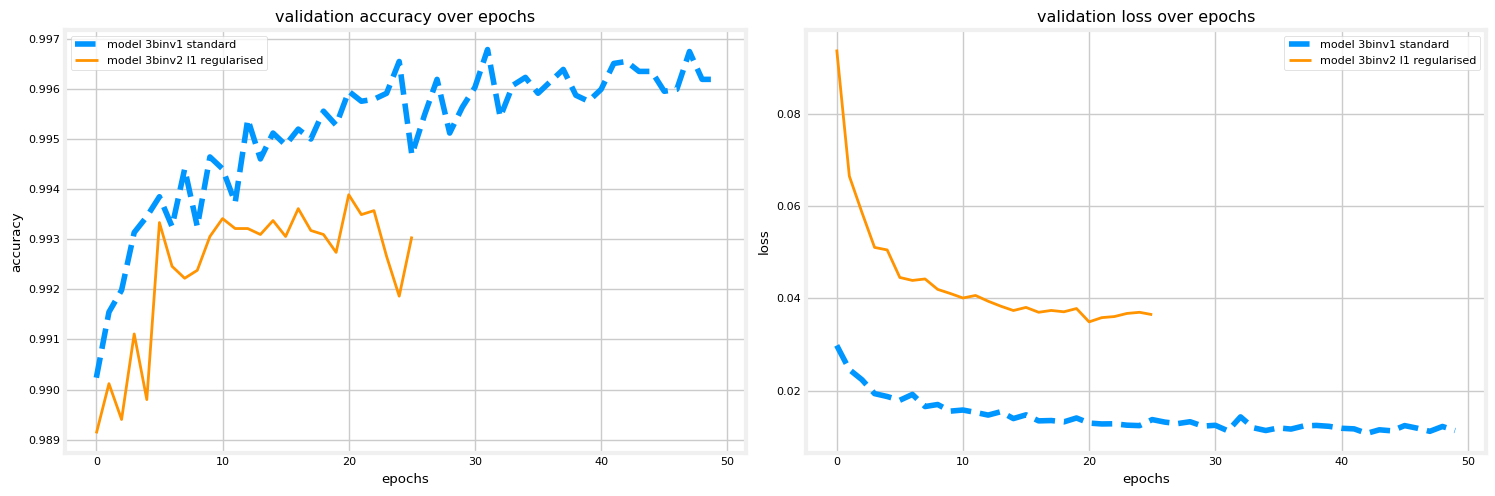

Final binary results
          Metric Model 3binv1 standard Model 3binv2 l1 regularised
0  Test accuracy                76.70%                      78.92%
1       Macro f1                  0.77                        0.79
2   Macro recall                  0.79                        0.81


In [ ]:
# plt.close('all') 
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# # Accuracy Plot
# ax1.plot(history_bin_3BINv1.history['val_accuracy'], label='Standard Binary', linestyle='--')
# ax1.plot(history_bin_3BINv2.history['val_accuracy'], label='L1 Reg Binary', linewidth=2)
# ax1.set_title('Binary Validation Accuracy')
# ax1.set_xlabel('Epochs')
# ax1.set_ylabel('Accuracy')
# ax1.legend()
# ax1.grid(True)

# # Loss Plot
# ax2.plot(history_bin_3BINv1.history['val_loss'], label='Standard Binary', linestyle='--')
# ax2.plot(history_bin_3BINv2.history['val_loss'], label='L1 Reg Binary', linewidth=2)
# ax2.set_title('Binary Validation Loss')
# ax2.set_xlabel('Epochs')
# ax2.set_ylabel('Loss')
# ax2.legend()
# ax2.grid(True)

# plt.show()

# results_df = pd.DataFrame({
#     "Metric": ["Test Accuracy", "Features Used"],
#     "Model 3BINv1 (Standard)": [f"{test_acc_3BINv1*100:.2f}%", "All 41 (Dense)"],
#     "Model 3BINv2 (L1 Regularized)": [f"{test_acc_3BINv2*100:.2f}%", "All 41 (Sparse/Filtered)"]
# })

# print("--- Final Project Results ---")
# print(results_df)



# Accuracy and loss comparison of both multi-classclassification models over epochs
# evaluate and generate predictions for 3binv1
test_loss_3BINv1, test_acc_3BINv1 = model_bin_3BINv1.evaluate(X_test, y_test_bin, verbose=2)
y_pred_3BINv1_probs = model_bin_3BINv1.predict(X_test).ravel()
y_pred_3BINv1 = (y_pred_3BINv1_probs >= 0.5).astype("int32")
report_3BINv1 = classification_report(
    y_test_bin,
    y_pred_3BINv1,
    output_dict=True,
    target_names=["Normal", "Attack"],
    zero_division=0
)

# evaluate and generate predictions for 3binv2
test_loss_3BINv2, test_acc_3BINv2 = model_bin_3BINv2.evaluate(X_test, y_test_bin, verbose=2)
y_pred_3BINv2_probs = model_bin_3BINv2.predict(X_test).ravel()
y_pred_3BINv2 = (y_pred_3BINv2_probs >= 0.5).astype("int32")
report_3BINv2 = classification_report(
    y_test_bin,
    y_pred_3BINv2,
    output_dict=True,
    target_names=["Normal", "Attack"],
    zero_division=0
)

# print the classification reports (same as multiclass)
print("Classification report 3binv1")
print(classification_report(
    y_test_bin,
    y_pred_3BINv1,
    target_names=["Normal", "Attack"],
    zero_division=0
))

print("Classification report 3binv2")
print(classification_report(
    y_test_bin,
    y_pred_3BINv2,
    target_names=["Normal", "Attack"],
    zero_division=0
))

# plots
plt.close("all")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history_bin_3BINv1.history["val_accuracy"], label="model 3binv1 standard", linestyle="--")
ax1.plot(history_bin_3BINv2.history["val_accuracy"], label="model 3binv2 l1 regularised", linewidth=2)
ax1.set_title("validation accuracy over epochs")
ax1.set_xlabel("epochs")
ax1.set_ylabel("accuracy")
ax1.legend()
ax1.grid(True)

ax2.plot(history_bin_3BINv1.history["val_loss"], label="model 3binv1 standard", linestyle="--")
ax2.plot(history_bin_3BINv2.history["val_loss"], label="model 3binv2 l1 regularised", linewidth=2)
ax2.set_title("validation loss over epochs")
ax2.set_xlabel("epochs")
ax2.set_ylabel("loss")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# results table with test accuracy, macro f1, macro recall (mirrors multiclass summary)
results_df = pd.DataFrame({
    "Metric": ["Test accuracy", "Macro f1", "Macro recall"],
    "Model 3binv1 standard": [
        f"{test_acc_3BINv1*100:.2f}%",
        f"{report_3BINv1['macro avg']['f1-score']:.2f}",
        f"{report_3BINv1['macro avg']['recall']:.2f}"
    ],
    "Model 3binv2 l1 regularised": [
        f"{test_acc_3BINv2*100:.2f}%",
        f"{report_3BINv2['macro avg']['f1-score']:.2f}",
        f"{report_3BINv2['macro avg']['recall']:.2f}"
    ]
})

print("Final binary results")
print(results_df)



The binary neural network results indicate that regularisation has a small positive effect in the simpler normal-versus-attack setting. Compared to the baseline model (3BINv1), the L1-regularised model with early stopping (3BINv2) achieves slightly higher test accuracy and modest improvements in macro-averaged recall and macro F1-score. These differences suggest that regularisation may help stabilise the decision boundary and marginally improve generalisation when distinguishing between normal and attack traffic, although the overall impact remains limited.

The validation curves support this interpretation. Both models converge rapidly and reach high validation accuracy, while the regularised model exhibits a smoother validation loss trajectory and terminates earlier due to early stopping. However, the differences in optimisation behaviour are minor, and both models display broadly similar convergence patterns.

Overall, the improvements observed in the binary setting are incremental rather than substantial. Unlike the multi-class task, where extreme class imbalance and overlapping attack categories strongly affect performance, the binary case is inherently less complex. In this setting, regularisation alone is sufficient to yield small refinements, but additional imbalance-aware techniques, such as class weighting, are unlikely to provide meaningful benefits. These findings reinforce the conclusion that neural networks offer limited advantages over simpler or tree-based models for binary intrusion detection.

## 6 - Visualisation
To complement the quantitative evaluation, additional visualisations are added to illustrate class-specific error patterns and threshold-dependent trade-offs. These analyses provide insight into why changes in model configuration lead to limited improvements, particularly for minority attack classes.

### 6.1 Visualisation multi-classification

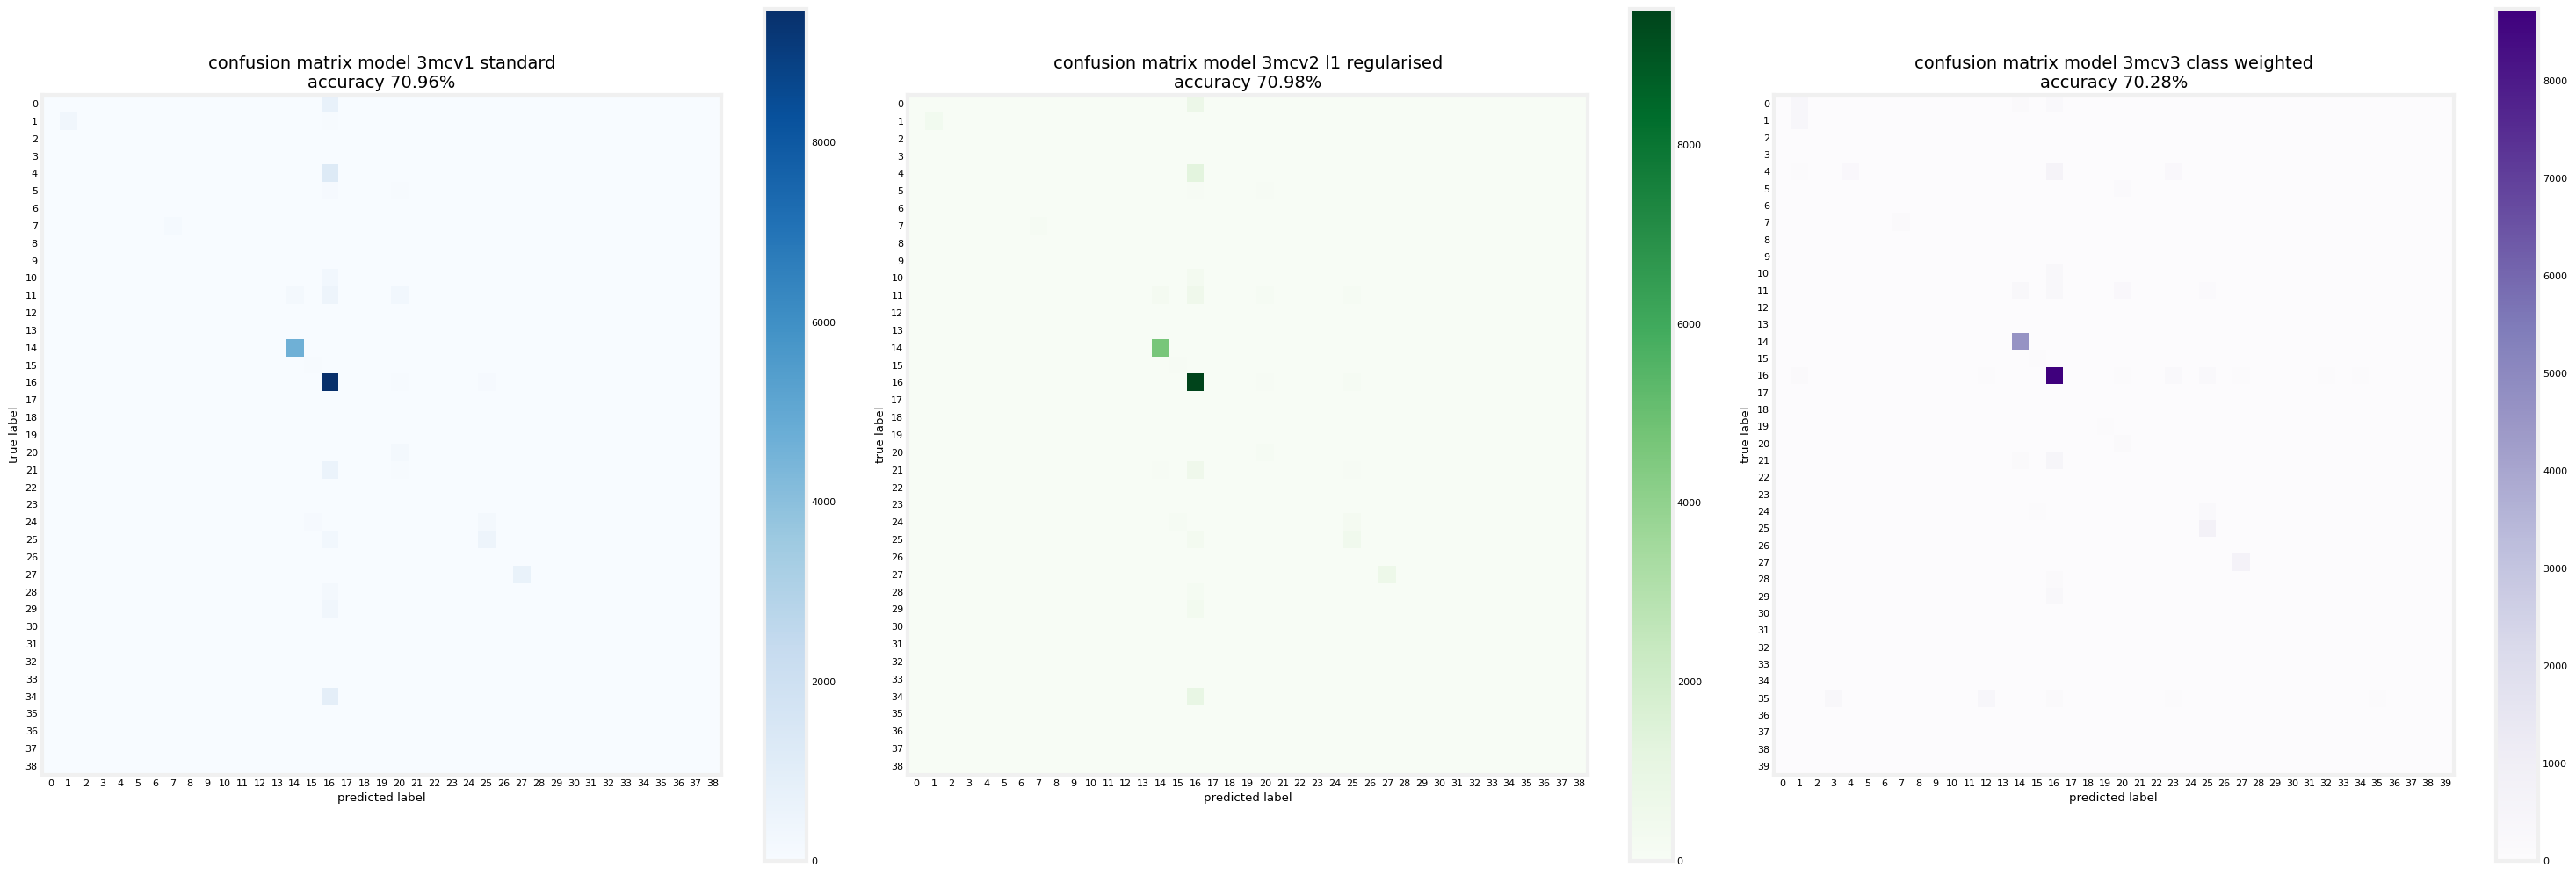

In [ ]:
plt.close("all")
fig, axes = plt.subplots(1, 3, figsize=(30, 10))

# model 3mcv1
cm1 = confusion_matrix(y_test, y_pred_3MCv1)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1)
disp1.plot(ax=axes[0], cmap="Blues", include_values=False, colorbar=True)
axes[0].set_title(
    f"confusion matrix model 3mcv1 standard\naccuracy {test_acc_3MCv1:.2%}",
    fontsize=14
)
axes[0].set_xlabel("predicted label")
axes[0].set_ylabel("true label")

# model 3mcv2
cm2 = confusion_matrix(y_test, y_pred_3MCv2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2)
disp2.plot(ax=axes[1], cmap="Greens", include_values=False, colorbar=True)
axes[1].set_title(
    f"confusion matrix model 3mcv2 l1 regularised\naccuracy {test_acc_3MCv2:.2%}",
    fontsize=14
)
axes[1].set_xlabel("predicted label")
axes[1].set_ylabel("true label")

# model 3mcv3
cm3 = confusion_matrix(y_test, y_pred_3MCv3)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3)
disp3.plot(ax=axes[2], cmap="Purples", include_values=False, colorbar=True)
axes[2].set_title(
    f"confusion matrix model 3mcv3 class weighted\naccuracy {test_acc_3MCv3:.2%}",
    fontsize=14
)
axes[2].set_xlabel("predicted label")
axes[2].set_ylabel("true label")

plt.tight_layout()
plt.show()


The confusion matrices show that all three multiclass neural network models exhibit very similar error patterns. Predictions are heavily concentrated on a small number of majority classes, while most minority classes are rarely, if ever, correctly identified. This visual pattern explains the low macro-averaged performance observed across all models.

Neither L1 regularisation nor class-weighted training leads to a meaningful change in how errors are distributed across classes. Although class weighting slightly shifts predictions for some minority classes, the overall structure of the confusion matrices remains largely unchanged. This indicates that these modifications do not fundamentally improve class separability.

Overall, the confusion matrices confirm that standard neural networks struggle with the extreme class imbalance and overlapping classes in the multi-class intrusion detection task, and they do not provide a clear advantage over tree-based methods in this setting.

### 6.2 Visualisation and optimalisation binary classification

Visualising model 3binv1 standard
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 727us/step


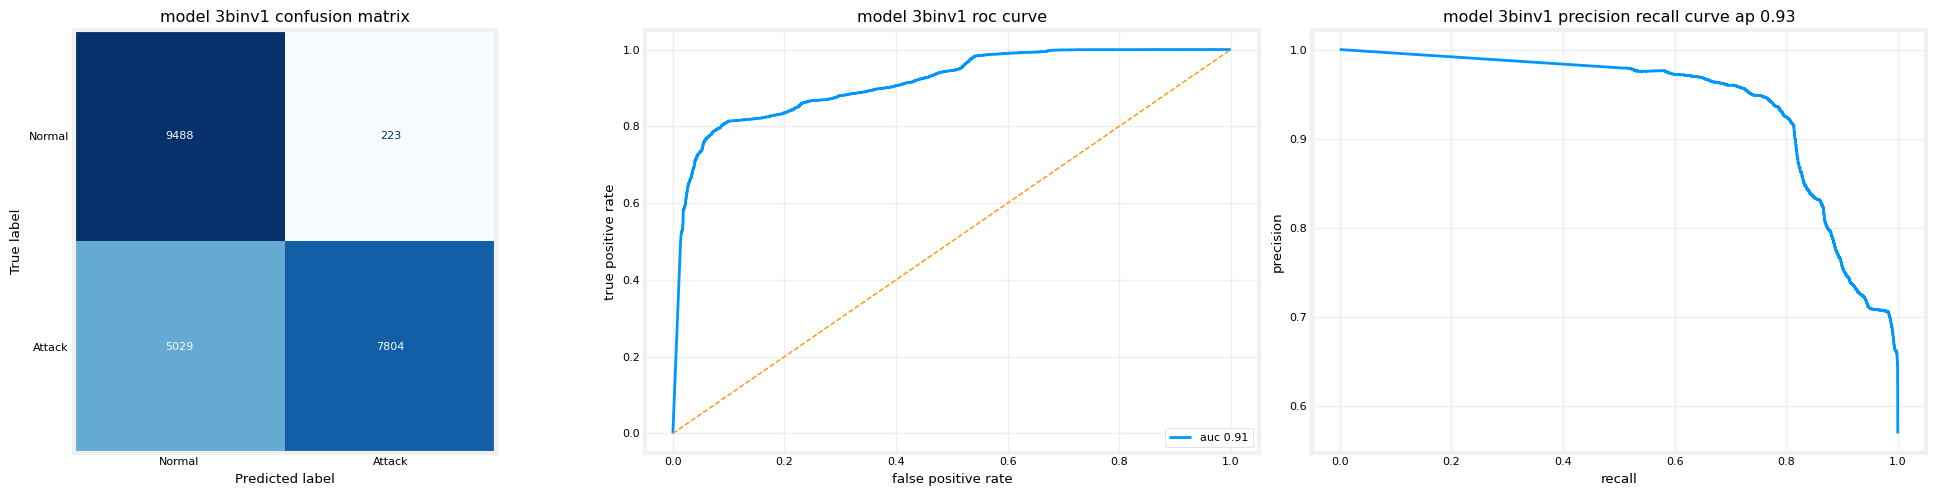

Visualising model 3binv2 l1 regularised
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 686us/step


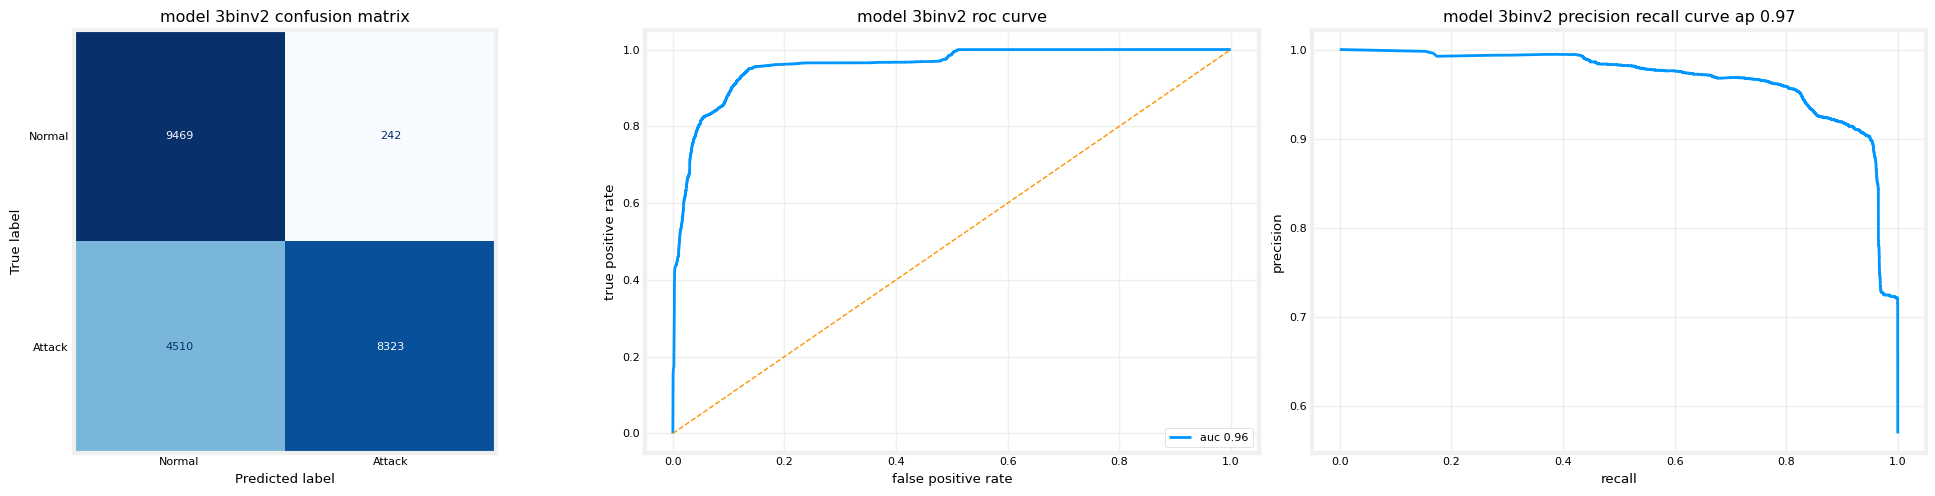

In [25]:
# def plot_performance_visuals(model, X_test, y_test, model_name):
#     y_pred_prob = model.predict(X_test).ravel()
#     y_pred = (y_pred_prob > 0.5).astype(int)

#     fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
#     cm = confusion_matrix(y_test, y_pred)
#     disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
#     disp.plot(cmap='Blues', ax=axes[0], colorbar=False)
#     axes[0].set_title(f'{model_name}: Confusion Matrix')

#     fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
#     roc_auc = auc(fpr, tpr)
#     axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
#     axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
#     axes[1].set_xlabel('False Positive Rate')
#     axes[1].set_ylabel('True Positive Rate (Recall)')
#     axes[1].set_title(f'{model_name}: ROC Curve')
#     axes[1].legend(loc="lower right")
#     axes[1].grid(alpha=0.3)

#     precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
#     axes[2].plot(recall, precision, color='green', lw=2)
#     axes[2].set_xlabel('Recall (Attacks Detected)')
#     axes[2].set_ylabel('Precision (Accuracy of Alarms)')
#     axes[2].set_title(f'{model_name}: Precision-Recall Curve')
#     axes[2].grid(alpha=0.3)
    
#     plt.tight_layout()
#     plt.show()

# print("--- Visualizing Model 3BINv1 (Standard) ---")
# plot_performance_visuals(model_bin_3BINv1, X_test, y_test_bin, "Model 3BINv1")

# print("\n--- Visualizing Model 3BINv2 (L1 Regularized) ---")
# plot_performance_visuals(model_bin_3BINv2, X_test, y_test_bin, "Model 3BINv2")

def plot_performance_visuals(model, X_test, y_test, model_name):
    y_pred_prob = model.predict(X_test).ravel()
    y_pred = (y_pred_prob >= 0.5).astype(int)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Attack"])
    disp.plot(cmap="Blues", ax=axes[0], colorbar=False, values_format="d")
    axes[0].set_title(f"{model_name} confusion matrix")

    # roc curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, lw=2, label=f"auc {roc_auc:.2f}")
    axes[1].plot([0, 1], [0, 1], lw=1, linestyle="--")
    axes[1].set_xlabel("false positive rate")
    axes[1].set_ylabel("true positive rate")
    axes[1].set_title(f"{model_name} roc curve")
    axes[1].legend(loc="lower right")
    axes[1].grid(alpha=0.3)

    # precision recall curve
    precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
    ap = average_precision_score(y_test, y_pred_prob)
    axes[2].plot(recall, precision, lw=2)
    axes[2].set_xlabel("recall")
    axes[2].set_ylabel("precision")
    axes[2].set_title(f"{model_name} precision recall curve ap {ap:.2f}")
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

print("Visualising model 3binv1 standard")
plot_performance_visuals(model_bin_3BINv1, X_test, y_test_bin, "model 3binv1")

print("Visualising model 3binv2 l1 regularised")
plot_performance_visuals(model_bin_3BINv2, X_test, y_test_bin, "model 3binv2")


The confusion matrices show that both binary neural network models correctly classify most normal traffic, while a non-negligible fraction of attack traffic is misclassified as normal. Compared to the baseline (3BINv1), the regularised model (3BINv2) shows a modest reduction in false negatives for attacks, indicating a small improvement in attack recall. However, the overall structure of the matrices remains very similar across models, suggesting that regularisation primarily refines the decision boundary rather than fundamentally changing the model’s behaviour.

The ROC curves show strong separability between normal and attack traffic for both models, with high AUC values. This indicates that both models are effective at ranking samples by likelihood of being an attack, even if a fixed threshold does not yield optimal classification performance. While the regularised model achieves a slightly higher AUC, this difference is small and is best interpreted as improved score calibration rather than a substantial increase in discriminative capability.

The precision–recall curves provide a more informative view for intrusion detection. Both models maintain high precision over a wide range of recall values, indicating that many attacks can be detected without a large increase in false alarms. The regularised model exhibits a marginally stronger precision–recall profile, reflected in a higher average precision score, but the overall difference between the curves remains limited.

Neural networks produce probability scores that must be converted into binary decisions using a threshold. The default threshold of 0.5 is arbitrary and may not provide the best balance between missed attacks and false alarms. Optimal threshold selection is therefore performed to identify a more suitable operating point based on validation performance. This step does not change the underlying model or its ranking ability, but refines how predictions are translated into decisions in a practical intrusion detection setting.

In [26]:
# def find_optimal_threshold(model, X_test, y_test, model_name):
#     y_pred_prob = model.predict(X_test).ravel()
#     thresholds = np.arange(0.0, 1.0, 0.01)
#     f1_scores = [f1_score(y_test, (y_pred_prob > t).astype(int)) for t in thresholds]
    
#     best_idx = np.argmax(f1_scores)
#     best_threshold = thresholds[best_idx]
#     best_f1 = f1_scores[best_idx]
    
#     print(f"\n--- {model_name} Optimization ---")
#     print(f"Optimal Threshold: {best_threshold:.2f} | Best F1 Score: {best_f1:.2f}")
#     return best_threshold

# thresh_v1 = find_optimal_threshold(model_bin_3BINv1, X_test, y_test_bin, "Model 3BINv1")
# thresh_v2 = find_optimal_threshold(model_bin_3BINv2, X_test, y_test_bin, "Model 3BINv2")

# y_pred_opt_v1 = (model_bin_3BINv1.predict(X_test).ravel() > thresh_v1).astype(int)
# y_pred_opt_v2 = (model_bin_3BINv2.predict(X_test).ravel() > thresh_v2).astype(int)

# print(f"\n=== Final Report: Model 3BINv1 (Threshold {thresh_v1:.2f}) ===")
# print(f"Accuracy: {accuracy_score(y_test_bin, y_pred_opt_v1) * 100:.2f}%")
# print(classification_report(y_test_bin, y_pred_opt_v1, target_names=['Normal', 'Attack']))

# print(f"\n=== Final Report: Model 3BINv2 (Threshold {thresh_v2:.2f}) ===")
# print(f"Accuracy: {accuracy_score(y_test_bin, y_pred_opt_v2) * 100:.2f}%")
# print(classification_report(y_test_bin, y_pred_opt_v2, target_names=['Normal', 'Attack']))

def find_optimal_threshold(model, X_val, y_val, model_name):
    y_val_prob = model.predict(X_val).ravel()
    thresholds = np.arange(0.0, 1.0, 0.01)
    f1_scores = [f1_score(y_val, (y_val_prob >= t).astype(int)) for t in thresholds]

    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print(f"{model_name} validation threshold optimisation")
    print(f"optimal threshold {best_threshold:.2f} best f1 {best_f1:.2f}")

    return best_threshold

thresh_v1 = find_optimal_threshold(model_bin_3BINv1, X_val, y_val_bin, "model 3binv1")
thresh_v2 = find_optimal_threshold(model_bin_3BINv2, X_val, y_val_bin, "model 3binv2")

y_pred_opt_v1 = (model_bin_3BINv1.predict(X_test).ravel() >= thresh_v1).astype(int)
y_pred_opt_v2 = (model_bin_3BINv2.predict(X_test).ravel() >= thresh_v2).astype(int)

print("Final report model 3binv1 threshold tuned")
print(f"accuracy {accuracy_score(y_test_bin, y_pred_opt_v1)*100:.2f}%")
print(classification_report(y_test_bin, y_pred_opt_v1, target_names=["Normal", "Attack"], zero_division=0))

print("Final report model 3binv2 threshold tuned")
print(f"accuracy {accuracy_score(y_test_bin, y_pred_opt_v2)*100:.2f}%")
print(classification_report(y_test_bin, y_pred_opt_v2, target_names=["Normal", "Attack"], zero_division=0))


788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
model 3binv1 validation threshold optimisation
optimal threshold 0.41 best f1 1.00
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 881us/step
model 3binv2 validation threshold optimisation
optimal threshold 0.56 best f1 0.99
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 870us/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 817us/step
Final report model 3binv1 threshold tuned
accuracy 77.43%
              precision    recall  f1-score   support

      Normal       0.66      0.98      0.79      9711
      Attack       0.97      0.62      0.76     12833

    accuracy                           0.77     22544
   macro avg       0.82      0.80      0.77     22544
weighted avg       0.84      0.77      0.77     22544

Final report model 3binv2 threshold tuned
accuracy 78.81%
              precision    recall  f1-score   support

      Normal       0.68      0.98      0.80      9711
      Attack       0.97      0.65      0.78     12833

    accuracy                           0.79     22544
   

Threshold tuning shows that the default threshold of 0.5 is not optimal for binary intrusion detection. Selecting an operating point based on validation performance leads to small but consistent improvements in attack recall and macro F1-score. However, these gains are limited and do not fundamentally change the model’s behaviour, confirming that threshold tuning is a practical refinement rather than a substantive performance improvement in this case.

To summarise the binary analysis, ROC and precision–recall curves are shown alongside confusion matrices evaluated at the optimised thresholds, illustrating both ranking performance and the resulting classification trade-offs.

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 801us/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 639us/step


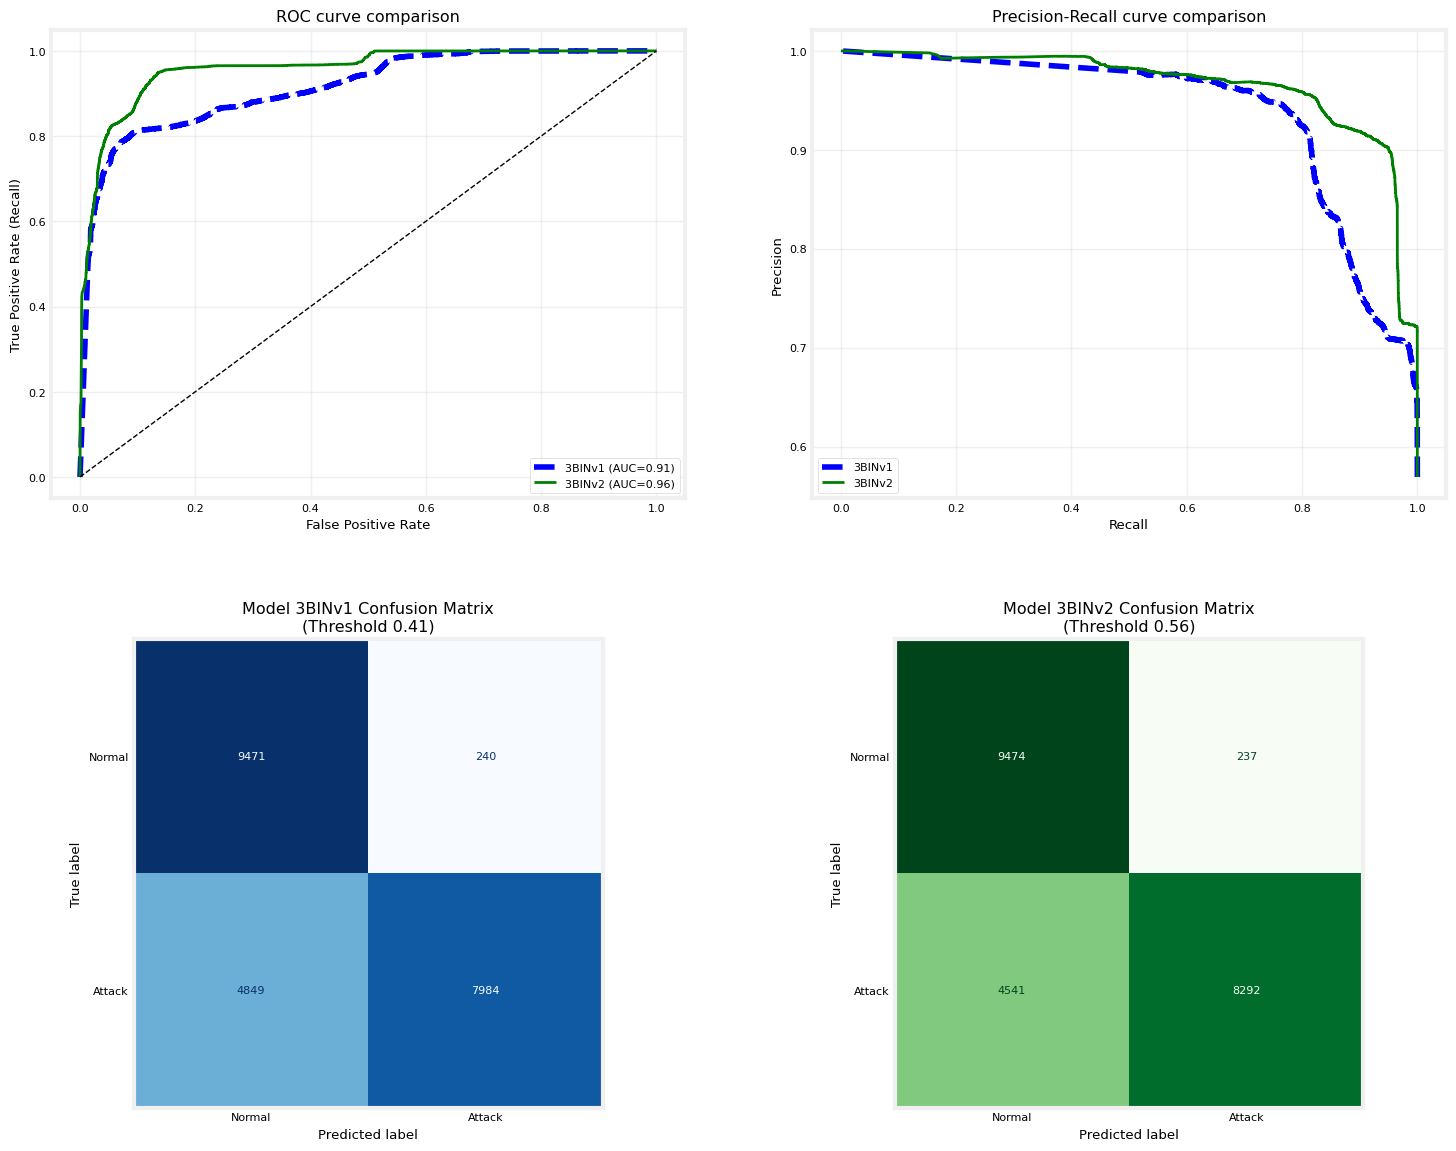

In [28]:
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve

y_prob_v1 = model_bin_3BINv1.predict(X_test).ravel()
y_prob_v2 = model_bin_3BINv2.predict(X_test).ravel()

# t1 = locals().get('thresh_v1', 0.01)
# t2 = locals().get('thresh_v2', 0.01)
t1 = thresh_v1 if "thresh_v1" in globals() else 0.5
t2 = thresh_v2 if "thresh_v2" in globals() else 0.5


fig, axes = plt.subplots(2, 2, figsize=(18, 14))
plt.subplots_adjust(hspace=0.3)

# Top Left: ROC Comparison
fpr1, tpr1, _ = roc_curve(y_test_bin, y_prob_v1)
fpr2, tpr2, _ = roc_curve(y_test_bin, y_prob_v2)
axes[0, 0].plot(fpr1, tpr1, linestyle='--', color='blue', label=f'3BINv1 (AUC={auc(fpr1, tpr1):.2f})')
axes[0, 0].plot(fpr2, tpr2, linewidth=2, color='green', label=f'3BINv2 (AUC={auc(fpr2, tpr2):.2f})')
axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 0].set_title('ROC curve comparison')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate (Recall)')
axes[0, 0].legend(loc="lower right")
axes[0, 0].grid(alpha=0.3)

# Top Right: Precision-Recall Comparison
p1, r1, _ = precision_recall_curve(y_test_bin, y_prob_v1)
p2, r2, _ = precision_recall_curve(y_test_bin, y_prob_v2)
axes[0, 1].plot(r1, p1, linestyle='--', color='blue', label='3BINv1')
axes[0, 1].plot(r2, p2, linewidth=2, color='green', label='3BINv2')
axes[0, 1].set_title('Precision-Recall curve comparison')
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].legend(loc="lower left")
axes[0, 1].grid(alpha=0.3)

# Bottom Left: Confusion Matrix 3BINv1
cm_v1 = confusion_matrix(y_test_bin, (y_prob_v1 >= t1).astype(int))
disp_v1 = ConfusionMatrixDisplay(confusion_matrix=cm_v1, display_labels=['Normal', 'Attack'])
disp_v1.plot(cmap='Blues', ax=axes[1, 0], colorbar=False)
axes[1, 0].set_title(f'Model 3BINv1 Confusion Matrix\n(Threshold {t1:.2f})')

# Bottom Right: Confusion Matrix 3BINv2
cm_v2 = confusion_matrix(y_test_bin, (y_prob_v2 >= t2).astype(int))
disp_v2 = ConfusionMatrixDisplay(confusion_matrix=cm_v2, display_labels=['Normal', 'Attack'])
disp_v2.plot(cmap='Greens', ax=axes[1, 1], colorbar=False)
axes[1, 1].set_title(f'Model 3BINv2 Confusion Matrix\n(Threshold {t2:.2f})')

plt.show()

The binary neural network models demonstrate comparable performance across all evaluation criteria. While the regularised model (3BINv2) consistently shows slightly higher ROC–AUC, average precision, and attack recall than the baseline model, these differences are small in magnitude. The confusion matrices before and after threshold tuning reveal broadly similar error structures, indicating that both models make similar types of mistakes and differ mainly in the calibration of their output scores rather than in their underlying decision boundaries.

Threshold tuning improves the balance between precision and recall for both models by selecting a more suitable operating point, but the resulting gains are incremental and do not materially change overall classification behaviour. After tuning, the performance gap between the two models narrows further, suggesting that much of the apparent advantage of the regularised model can be attributed to improved score calibration rather than to a fundamentally superior representation of attack patterns.

Overall, while regularisation and threshold adjustment provide modest refinements, there is no strong evidence that Model 3BINv2 offers a statistically or practically significant advantage over the baseline binary neural network. These findings reinforce the conclusion that, in the binary intrusion detection setting, neural network variants yield limited improvements and do not clearly outperform simpler or tree-based approaches.